In [27]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt

from sklearn.model_selection import train_test_split
from sklearn.linear_model import LinearRegression
from sklearn.cluster import KMeans
from sklearn.metrics import mean_squared_error, r2_score
from sklearn.metrics import silhouette_score, calinski_harabasz_score, davies_bouldin_score


In [28]:
def load_dataset(path):
    data = pd.read_csv(path, sep=';')
    return data
    

In [29]:
def prepare_data(data, target):
    X = data.drop(columns=[target])
    y = data[target]

    X_train, X_test, y_train, y_test = train_test_split(
        X, y, test_size=0.2, random_state=42
    )

    return X_train, X_test, y_train, y_test
    

In [30]:
def train_linear_regression(X_train, y_train):
    model = LinearRegression()
    model.fit(X_train, y_train)
    return model


In [31]:
def regression_metrics(y_true, y_pred):

    mse = mean_squared_error(y_true, y_pred)
    rmse = np.sqrt(mse)

    mape = np.mean(np.abs((y_true - y_pred) / y_true)) * 100

    r2 = r2_score(y_true, y_pred)

    return mse, rmse, mape, r2

In [32]:
def perform_kmeans(X, k):

    kmeans = KMeans(n_clusters=k, random_state=42, n_init="auto")
    kmeans.fit(X)

    return kmeans
    

In [33]:
def clustering_scores(X, labels):

    sil = silhouette_score(X, labels)
    ch = calinski_harabasz_score(X, labels)
    db = davies_bouldin_score(X, labels)

    return sil, ch, db


In [34]:
def evaluate_k_values(X, k_range):

    sil_scores = []
    ch_scores = []
    db_scores = []

    for k in k_range:

        kmeans = perform_kmeans(X, k)
        labels = kmeans.labels_

        sil, ch, db = clustering_scores(X, labels)

        sil_scores.append(sil)
        ch_scores.append(ch)
        db_scores.append(db)

    return sil_scores, ch_scores, db_scores
    

In [35]:
def elbow_method(X, k_range):

    distortions = []

    for k in k_range:
        kmeans = perform_kmeans(X, k)
        distortions.append(kmeans.inertia_)

    return distortions
    

In [36]:
def plot_scores(k_range, values, title, ylabel):

    plt.figure()
    plt.plot(k_range, values, marker='o')
    plt.title(title)
    plt.xlabel("Number of Clusters (k)")
    plt.ylabel(ylabel)
    plt.show()

Single Attribute Model
Train Metrics: (0.5052353129203041, np.float64(0.7107990664880646), np.float64(10.27714288745149), 0.22342286653631416)
Test Metrics: (0.4995281340730444, np.float64(0.706773042831321), np.float64(10.280103398263355), 0.23561797203963386)

Multiple Attribute Model
Train Metrics: (0.4241911573139901, np.float64(0.6512995910592836), np.float64(9.200689541929014), 0.3479926193529862)
Test Metrics: (0.39002514396395427, np.float64(0.6245199307980125), np.float64(8.991084943366381), 0.403180341279623)

Cluster Centers
[[8.42425785e+00 5.19334182e-01 2.66539440e-01 2.39427481e+00
  8.54461408e-02 1.23719254e+01 3.03443596e+01 9.96676836e-01
  3.31552163e+00 6.56530958e-01 1.05402177e+01]
 [8.02595238e+00 5.51642857e-01 2.83428571e-01 2.94452381e+00
  9.31380952e-02 2.57083333e+01 9.17285714e+01 9.96942738e-01
  3.29873810e+00 6.62690476e-01 1.00938889e+01]]

Clustering Scores
Silhouette: 0.6034220347331241
Calinski-Harabasz: 2820.8950335013647
Davies-Bouldin: 0.6169926

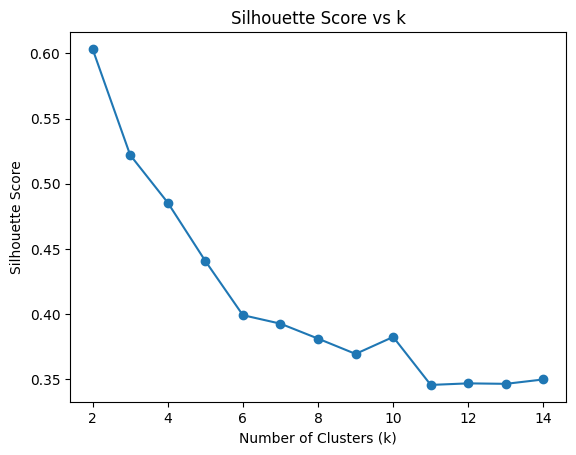

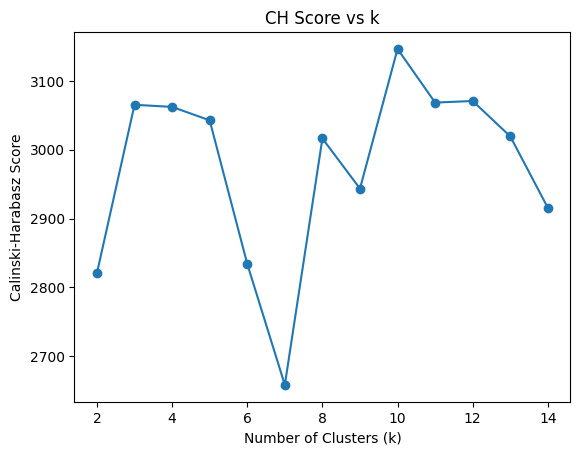

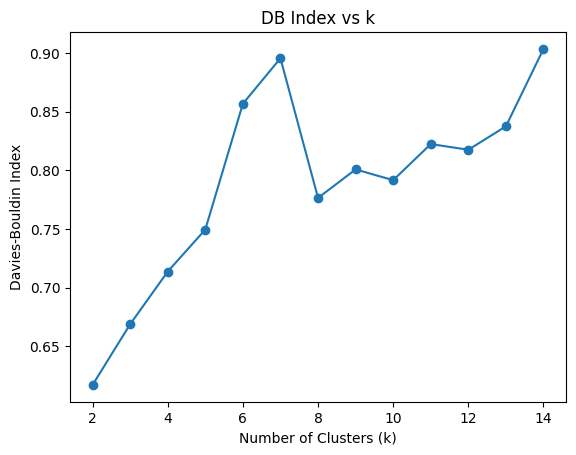

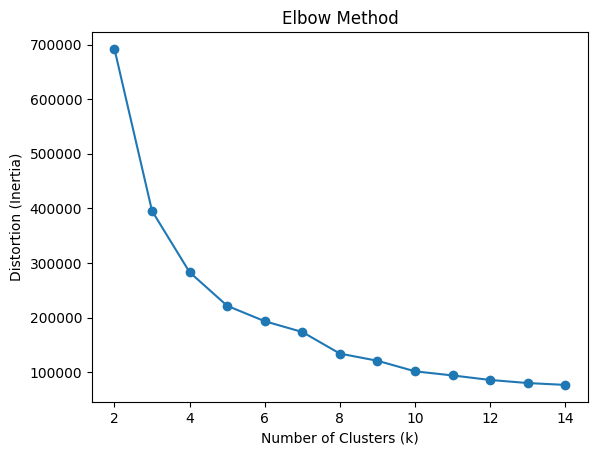

In [37]:
# Load dataset
data = load_dataset(r"C:\Users\Hritik Muji\Jupyter\LABS\LAB 4\dataset/winequality-red.csv")

# Prepare data
X_train, X_test, y_train, y_test = prepare_data(data, "quality")

# -------------------------
# A1 & A2 Linear Regression (Single Attribute)
# -------------------------

X_train_single = X_train[['alcohol']]
X_test_single = X_test[['alcohol']]

model_single = train_linear_regression(X_train_single, y_train)

train_pred = model_single.predict(X_train_single)
test_pred = model_single.predict(X_test_single)

train_metrics = regression_metrics(y_train, train_pred)
test_metrics = regression_metrics(y_test, test_pred)

print("Single Attribute Model")
print("Train Metrics:", train_metrics)
print("Test Metrics:", test_metrics)


# -------------------------
# A3 Linear Regression (All Attributes)
# -------------------------

model_multi = train_linear_regression(X_train, y_train)

train_pred_multi = model_multi.predict(X_train)
test_pred_multi = model_multi.predict(X_test)

train_metrics_multi = regression_metrics(y_train, train_pred_multi)
test_metrics_multi = regression_metrics(y_test, test_pred_multi)

print("\nMultiple Attribute Model")
print("Train Metrics:", train_metrics_multi)
print("Test Metrics:", test_metrics_multi)


# -------------------------
# A4 K-Means Clustering
# -------------------------

X_cluster = data.drop(columns=["quality"])

kmeans = perform_kmeans(X_cluster, 2)

labels = kmeans.labels_

print("\nCluster Centers")
print(kmeans.cluster_centers_)


# -------------------------
# A5 Clustering Metrics
# -------------------------

sil, ch, db = clustering_scores(X_cluster, labels)

print("\nClustering Scores")
print("Silhouette:", sil)
print("Calinski-Harabasz:", ch)
print("Davies-Bouldin:", db)


# -------------------------
# A6 Different k Values
# -------------------------

k_range = range(2, 15)

sil_scores, ch_scores, db_scores = evaluate_k_values(X_cluster, k_range)

plot_scores(k_range, sil_scores, "Silhouette Score vs k", "Silhouette Score")
plot_scores(k_range, ch_scores, "CH Score vs k", "Calinski-Harabasz Score")
plot_scores(k_range, db_scores, "DB Index vs k", "Davies-Bouldin Index")


# -------------------------
# A7 Elbow Method
# -------------------------

distortions = elbow_method(X_cluster, k_range)

plot_scores(k_range, distortions, "Elbow Method", "Distortion (Inertia)")